In [2]:
import numpy as np

#预测数据检查
reslt_u = np.load('/home/yc/RecFNO/8×Resolution/logs/ckpt/superResolution_4×_FNO_CBAM/npy/test_pred_u.npy')
print(reslt_u.shape)
frame_idx = 1
sr = reslt_u[frame_idx]
print(sr.shape)
# sr = np.squeeze(sr,0)
print(sr.shape)
# sr = np.squeeze(sr,axis=1)

#高分辨率数据检查
# gt = np.load("data/test_cropped.npy")
gt = np.load("/data_new/OceanSR/split_ocean_dataset_seq/test/hr/ubar_hr_test.npy")
print(gt.shape)
gt = gt[frame_idx]
# gt = np.squeeze(gt,0)

#低分辨率数据检查
lq = np.load("/home/yc/RecFNO/8×Resolution/processed_data/test/bicubic_hr/ubar_bicubic_hr_test.npy")
# lq = np.load('data/lq_cropped.npy')
print(lq.shape)
lq = lq[frame_idx]

#掩膜数据
mask_path = "/data_new/OceanSR/split_ocean_dataset_seq/test/static/mask_hr_full.npy"
# mask_path = "data/mask_cropped.npy"
mask = np.load(mask_path)
print(mask.shape)
sr = np.where(mask, sr, np.nan)
gt = np.where(mask, gt, np.nan)
lq = np.where(mask, lq, np.nan)

(1060, 400, 400)
(400, 400)
(400, 400)
(1060, 400, 400)
(1060, 400, 400)
(400, 400)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.cm as cm
lon_path = "/data_new/OceanSR/split_ocean_dataset_seq/test/static/lon_hr_full.npy"
# lon_path = "data/lon_cropped.npy"
lat_path = "/data_new/OceanSR/split_ocean_dataset_seq/test/static/lat_hr_full.npy"
# lat_path = "data/lat_cropped.npy"
mask_path = "/data_new/OceanSR/split_ocean_dataset_seq/test/static/mask_hr_full.npy"
# mask_path = "data/mask_cropped.npy"
# gt = np.load(gt_path)
# lq = np.load(lq_path)
# timeline = np.load(timeline_path)
lon = np.load(lon_path)
lat = np.load(lat_path)
mask = np.load(mask_path)

# save_dir = f'/home/lzy/projects/ResShift/result_check/{result_dir}/step{num_step}'
# if not os.path.exists(save_dir):
#     os.makedirs(save_dir)
save_dir = f'/home/yc/RecFNO/8×Resolution/logs/ckpt/superResolution_4×_FNO_CBAM/figure'

In [4]:
# sr = timeline[num_batch, -1, :, :]
# sr = timeline[0, -1, :, :]  # IGNORE
sr.shape, gt.shape, lq.shape, lon.shape, lat.shape, mask.shape

((400, 400), (400, 400), (400, 400), (400, 400), (400, 400), (400, 400))

min value: -0.7279724478721619, max value: 0.3562973737716675


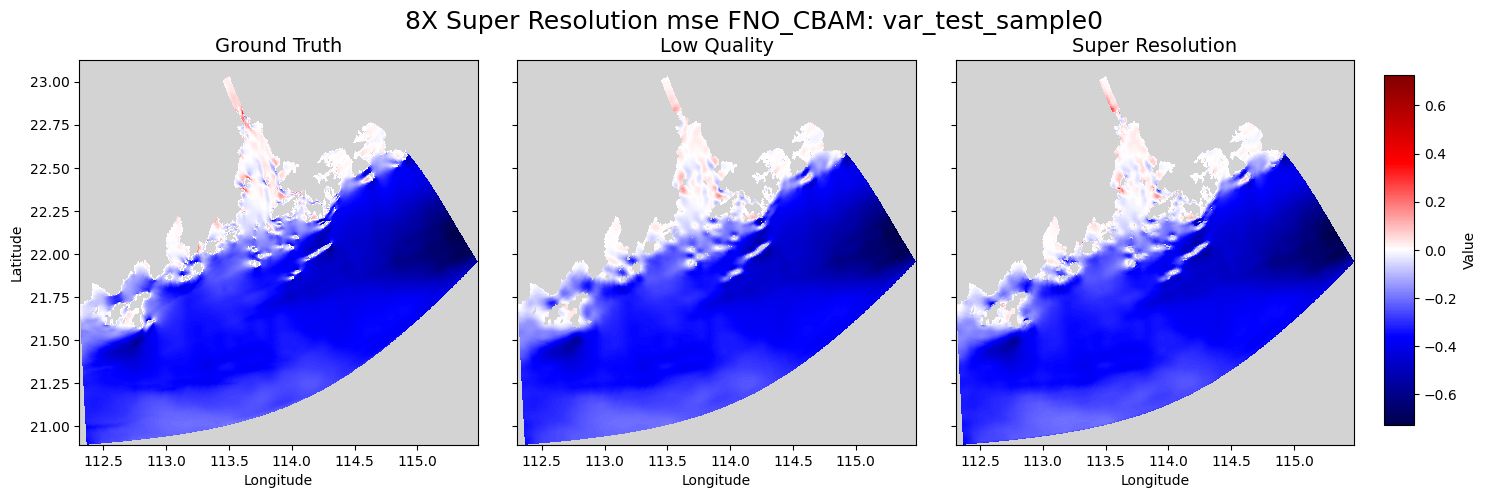

In [9]:
titles = ['Ground Truth', 'Low Quality', 'Super Resolution']
images = [gt, lq, sr]
# images = [gt, sr]
fig, axes = plt.subplots(1, 3, figsize=(15, 5),
                         sharex=True, sharey=True)

vmin = min(np.nanmin(d) for d in images)
vmax = max(np.nanmax(d) for d in images)
print(f'min value: {vmin}, max value: {vmax}') 
bound = max(abs(vmin), abs(vmax)) # 用bound让0在色条中间

for ax, data, title in zip(axes, images, titles):
    # 用 pcolormesh 更精确地对应 lon/lat 网格
    pcm = ax.pcolormesh(lon, lat, data,
                        cmap='seismic',
                        shading='auto',
                        vmax=bound, vmin=-bound) # 保证在同一colorbar下
    ax.set_facecolor('lightgray')  # 设置背景色
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Longitude')

# 在最右侧创建一个 colorbar，且跨越所有子图高度
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
axes[0].set_ylabel('Latitude')
fig.colorbar(pcm, cax=cbar_ax, label='Value')

# Adjust layout to leave space on the left and right
# fig.suptitle(f'4X Super Resolution: {var_name}_val_b{num_batch}_step{num_step}', fontsize=18, y=0.98)
fig.suptitle(f'8X Super Resolution mse FNO_CBAM: var_test_sample0', fontsize=18, y=0.98)
# fig.suptitle(f'256 Super Resolution128*128 modes36: var_test_sample0', fontsize=18, y=0.98)
# fig.suptitle(f'2X Reconstruction Super Resolution: var_test_sample0', fontsize=18, y=0.98)
plt.subplots_adjust(left=0.05, right=0.9, wspace=0.1)
# plt.savefig(f'{save_dir}/{var_name}_val_b{num_batch}_step{num_step}.png', bbox_inches='tight', dpi=300)
plt.savefig(f'{save_dir}/var_test_ubar_sample0_4×training.png', bbox_inches='tight', dpi=300)

plt.show()

In [10]:
lq_error_abs = np.abs(lq - gt)
sr_error_abs = np.abs(sr - gt)
lq_sr_error_abs = np.abs(lq - sr)
lq_error_abs_mean = np.nanmean(lq_sr_error_abs)
sr_error_abs_mean = np.nanmean(sr_error_abs)
print(f'lq error abs: {lq_error_abs_mean}, sr error abs: {sr_error_abs_mean}')

# titles = [f'lq_error: {lq_error_abs_mean}',f'sr_error: {sr_error_abs_mean}',f'lq_sr_error']
# fig, axes = plt.subplots(1, 2, figsize=(10, 5),
#                          sharex=True, sharey=True)

# vmin = min(np.nanmin(d) for d in [lq_error_abs, sr_error_abs])
# vmax = max(np.nanmax(d) for d in [lq_error_abs, sr_error_abs])
# bound = max(abs(vmin), abs(vmax))  # 用bound让0在色条中间
# # 绘每一幅图
# for ax, data, title in zip(axes, [lq_error_abs, sr_error_abs], titles):
#     # 用 pcolormesh 更精确地对应 lon/lat 网格
#     pcm = ax.pcolormesh(lon, lat, data,
#                         cmap='seismic',
#                         shading='auto',
#                         vmax=bound, vmin=-bound)
#     ax.set_facecolor('lightgray')  # 设置背景色
#     ax.set_title(title, fontsize=14)
#     ax.set_xlabel('Longitude')

# axes[0].set_ylabel('Latitude')
# # 在最右侧创建一个 colorbar，且跨越所有子图高度
# cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
# fig.colorbar(pcm, cax=cbar_ax, label='Value')

# # 调整布局，给左侧和右侧留空
# fig.suptitle(f'4X Super Resolution: {var_name}_val_b{num_batch}_step{num_step}', fontsize=18, y=0.98)
# plt.subplots_adjust(left=0.05, right=0.9, wspace=0.1)
# plt.savefig(f'{save_dir}/{var_name}_val_b{num_batch}_step{num_step}_error_abs.png', bbox_inches='tight', dpi=300)
# plt.show()

lq error abs: 0.0057095070369541645, sr error abs: 0.010889004915952682


lq_min_error: -0.6187712550163269, lq_max_error: 0.40885746479034424


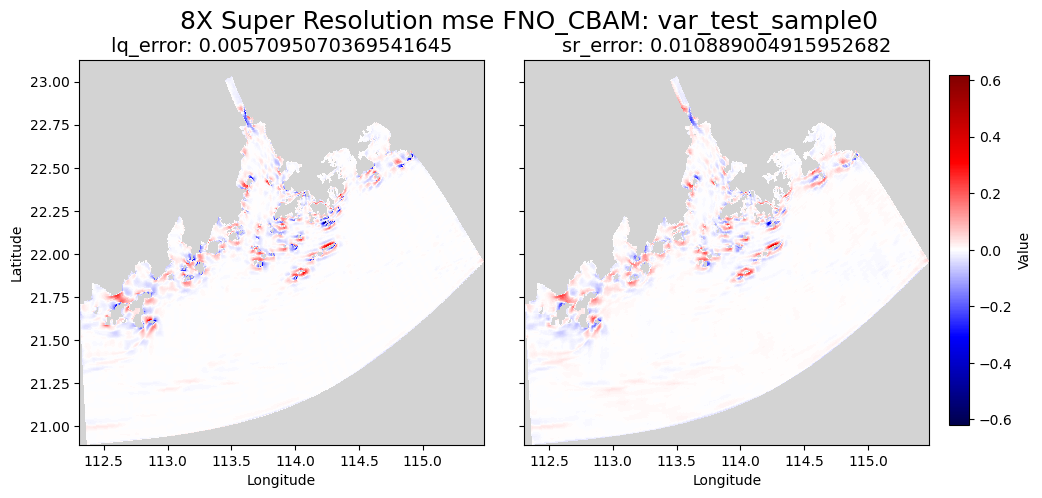

In [11]:
lq_error = lq - gt
sr_error = sr - gt
lq_sr_error = lq - sr

titles = [f'lq_error: {lq_error_abs_mean}',f'sr_error: {sr_error_abs_mean}']
fig, axes = plt.subplots(1, 2, figsize=(10, 5),
                         sharex=True, sharey=True)

vmin = min(np.nanmin(lq_error), np.nanmin(sr_error), np.nanmin(lq_sr_error))
vmax = max(np.nanmax(lq_error), np.nanmax(sr_error), np.nanmax(lq_sr_error))
bound = max(abs(vmin), abs(vmax)) # 用bound让0为中心

print(f'lq_min_error: {vmin}, lq_max_error: {vmax}')

# 绘每一幅图
for ax, data, title in zip(axes, [lq_error, sr_error], titles):
    # 用 pcolormesh 更精确地对应 lon/lat 网格
    pcm = ax.pcolormesh(lon, lat, data,
                        cmap='seismic',
                        shading='auto',
                        vmax=bound, vmin=-bound)  # 保证在同一colorbar下
    ax.set_facecolor('lightgray')  # 设置背景色
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Longitude')

axes[0].set_ylabel('Latitude')
# 在最右侧创建一个 colorbar，且跨越所有子图高度
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(pcm, cax=cbar_ax, label='Value')

# 调整布局，给左侧和右侧留空
# fig.suptitle(f'4X Super Resolution: {var_name}_val_b{num_batch}_step{num_step}', fontsize=18, y=0.98)
# fig.suptitle(f'4X Super Resolution: var_test_sample0', fontsize=18, y=0.98)
# fig.suptitle(f'256 Reconstruction Super Resolution128*128: var_test_sample0', fontsize=18, y=0.98)
fig.suptitle(f'8X Super Resolution mse FNO_CBAM: var_test_sample0', fontsize=18, y=0.98)
plt.subplots_adjust(left=0.05, right=0.9, wspace=0.1)
# plt.savefig(f'{save_dir}/{var_name}_val_b{num_batch}_step{num_step}_error_diff.png', bbox_inches='tight', dpi=300)
plt.savefig(f'{save_dir}/var_test_ubar_sample0_error_4×training.png', bbox_inches='tight', dpi=300)
plt.show()

sr min error: -0.42568811774253845, sr max error: 0.40885746479034424


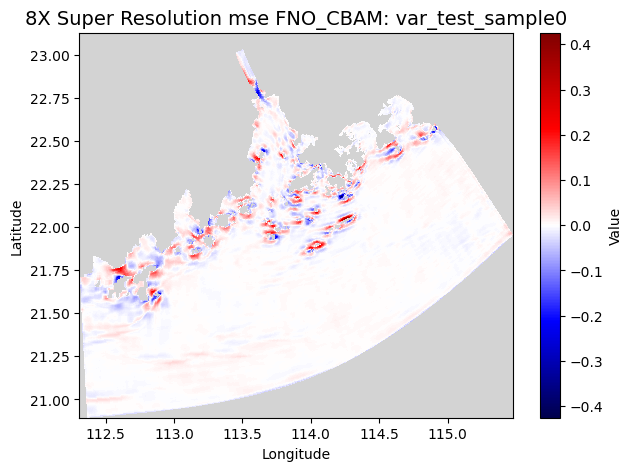

In [12]:
sr_bound = max(abs(np.nanmin(sr_error)), abs(np.nanmax(sr_error)))  # 用bound让0为中心
print(f'sr min error: {np.nanmin(sr_error)}, sr max error: {np.nanmax(sr_error)}')

plt.figure(figsize=(7, 5))
plt.pcolormesh(lon, lat, sr_error,
               cmap='seismic',
               shading='auto',
               vmax=sr_bound, vmin=-sr_bound)
plt.gca().set_facecolor('lightgray')  # 设置背景色
# plt.title(f'4X Super Resolution Error: {var_name}_val_b{num_batch}_step{num_step}', fontsize=14)
# plt.title(f'4X Super Resolution: var_test_sample0', fontsize=14)
# plt.title(f'256 Reconstruction Super Resolution: var_test_sample0', fontsize=14)
plt.title(f'8X Super Resolution mse FNO_CBAM: var_test_sample0', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label='Value')
# plt.savefig(f'{save_dir}/{var_name}_val_b{num_batch}_step{num_step}_sr_error.png', bbox_inches='tight', dpi=300)
plt.savefig(f'{save_dir}/var_test_ubar_sample0_sr_4×training.png', bbox_inches='tight', dpi=300)
plt.show()

/tmp/ipykernel_41622/1910881655.py:274: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1]) # [left, bottom, right, top]  # 调整上边距以容纳标题


Image saved to /home/lzy/projects/ResShift/tmp/comparison_step10_b0_log_relative_l2.png


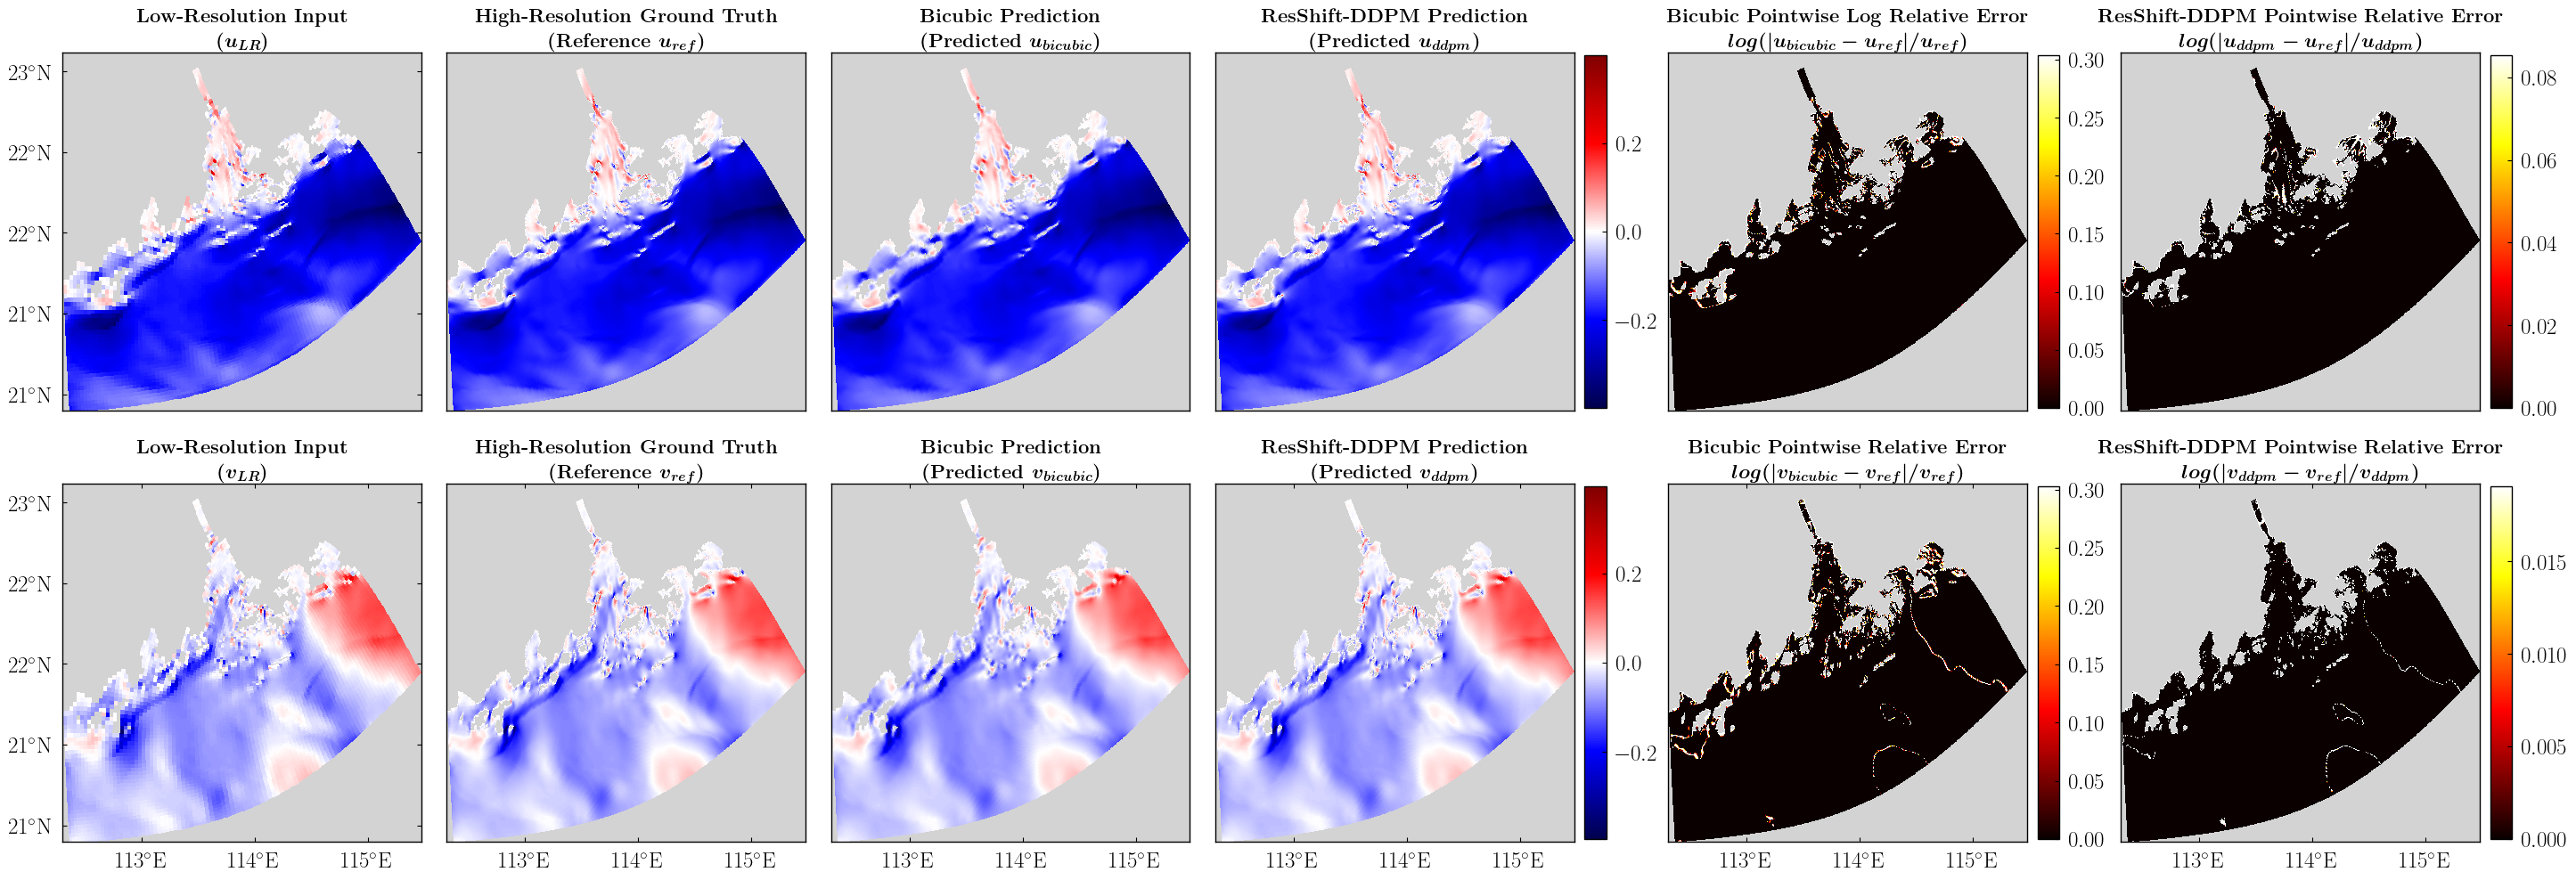

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import FuncFormatter
# 设置Matplotlib参数
plt.rc('text', usetex=True)
plt.rc('font', family='Times New Roman', size=18)
plt.rc('axes', linewidth=1, labelsize=18)
plt.rc('lines', linewidth=1, markersize=4)
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.major.pad'] = 7.5
plt.rcParams['ytick.major.pad'] = 7.5
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}' # 确保amsmath被加载
plt.rcParams['text.usetex'] = True

# --- 数据加载部分保持不变 ---
step_num = 10
batch = 0
base_dir = '/home/lzy/projects/ResShift/save_dir/2025-07-25-13-44_completeResult/data_plot/val'
save_dir = '/home/lzy/projects/ResShift/tmp'
os.makedirs(save_dir, exist_ok=True)

# 加载数据
ubar_gt = np.load(os.path.join(base_dir, f'ubar_gt_b{batch}_step{step_num}.npy'))
ubar_input = ubar_gt[::4, ::4]  # 仅用于可视化输入
ubar_lq = np.load(os.path.join(base_dir, f'ubar_lq_b{batch}_step{step_num}.npy'))
ubar_predTimeline = np.load(os.path.join(base_dir, f'ubar_progress_timeline-{step_num}.npy'))
ubar_pred = ubar_predTimeline[batch, -1, :, :]
ubar_lq_error = np.abs(ubar_lq - ubar_gt)
ubar_pred_error = np.abs(ubar_pred - ubar_gt)

ubar_lq_relative_error = np.log10(np.abs(ubar_lq_error) / np.abs(ubar_gt))  
ubar_pred_relative_error = np.log10(np.abs(ubar_pred_error) / np.abs(ubar_gt))  

# log_ubar_gt = np.log10(np.abs(ubar_gt) + 1e-8)  # 避免对0取对数
# log_ubar_lq = np.log10(np.abs(ubar_lq) + 1e-8)  # 避免对0取对数
# log_ubar_pred = np.log10(np.abs(ubar_pred) + 1e-8)  # 避免对0取对数
# log_ubar_lq_error = np.log10(np.abs(ubar_lq_error) / np.abs(ubar_gt) + 1e-8)  # 避免对0取对数
# log_ubar_pred_error = np.log10(np.abs(ubar_pred_error) / np.abs(ubar_gt) + 1e-8)  # 避免对0取对数

vbar_gt = np.load(os.path.join(base_dir, f'vbar_gt_b{batch}_step{step_num}.npy'))
vbar_input = vbar_gt[::4, ::4]  # 仅用于可视化输入
vbar_lq = np.load(os.path.join(base_dir, f'vbar_lq_b{batch}_step{step_num}.npy'))
vbar_predTimeline = np.load(os.path.join(base_dir, f'vbar_progress_timeline-{step_num}.npy'))
vbar_pred = vbar_predTimeline[batch, -1, :, :]
vbar_lq_error = np.abs(vbar_lq - vbar_gt)
vbar_pred_error = np.abs(vbar_pred - vbar_gt)

vbar_lq_relative_error = np.log10(np.abs(vbar_lq_error) / np.abs(vbar_gt))  
vbar_pred_relative_error = np.log10(np.abs(vbar_pred_error) / np.abs(vbar_gt))  
# log_vbar_gt = np.log10(np.abs(vbar_gt) + 1e-8)  # 避免对0取对数
# log_vbar_lq = np.log10(np.abs(vbar_lq) + 1e-8)  # 避免对0取对数
# log_vbar_pred = np.log10(np.abs(vbar_pred) + 1e-8)  # 避免对0取对数
# log_vbar_lq_error = np.log10(np.abs(vbar_lq_error) / np.abs(vbar_gt) + 1e-8)  # 避免对0取对数
# log_vbar_pred_error = np.log10(np.abs(vbar_pred_error) / np.abs(vbar_gt) + 1e-8)  # 避免对0取对数

longitude = np.load('/data/OceanSR/split_ocean_dataset_seq/train/static/lon_hr_full.npy')
latitude = np.load('/data/OceanSR/split_ocean_dataset_seq/train/static/lat_hr_full.npy')

# data = [
#     [ubar_input, ubar_gt, ubar_lq, ubar_pred, ubar_lq_error, ubar_pred_error],
#     [vbar_input, vbar_gt, vbar_lq, vbar_pred, vbar_lq_error, vbar_pred_error]
# ]

data = [
    [ubar_input, ubar_gt, ubar_lq, ubar_pred, ubar_lq_relative_error, ubar_pred_relative_error],
    [vbar_input, vbar_gt, vbar_lq, vbar_pred, vbar_lq_relative_error, vbar_pred_relative_error]
]
titles = [[r'\begin{center} \textbf{Low-Resolution Input \\ ($\boldsymbol{u_{LR}}$)} \end{center}', 
           r'\begin{center} \textbf{High-Resolution Ground Truth \\ (Reference $\boldsymbol{u_{ref}}$)} \end{center}',
           r'\begin{center} \textbf{Bicubic Prediction \\ (Predicted $\boldsymbol{u_{bicubic}}$)} \end{center}', 
           r'\begin{center} \textbf{EnhancedFNO Prediction \\ (Predicted $\boldsymbol{u_{ddpm}}$)} \end{center}',
           r'\begin{center} \textbf{Bicubic Pointwise Log Relative Error} \\  $\boldsymbol{log(| u_{bicubic} - u_{ref} | / u_{ref})}$ \end{center}', 
           r'\begin{center} \textbf{EnhancedFNO Pointwise Relative Error} \\  $\boldsymbol{log(| u_{ddpm} - u_{ref} | / u_{ddpm})}$ \end{center}'],
          [r'\begin{center} \textbf{Low-Resolution Input \\ ($\boldsymbol{v_{LR}}$)} \end{center}', 
           r'\begin{center} \textbf{High-Resolution Ground Truth \\ (Reference $\boldsymbol{v_{ref}}$)} \end{center}',
           r'\begin{center} \textbf{Bicubic Prediction \\ (Predicted $\boldsymbol{v_{bicubic}}$)} \end{center}', 
           r'\begin{center} \textbf{EnhancedFNO Prediction \\ (Predicted $\boldsymbol{v_{ddpm}}$)} \end{center}',
           r'\begin{center} \textbf{Bicubic Pointwise Relative Error} \\  $\boldsymbol{log(| v_{bicubic} - v_{ref} | / v_{ref})}$ \end{center}', 
           r'\begin{center} \textbf{EnhancedFNO Pointwise Relative Error} \\  $\boldsymbol{log(| v_{ddpm} - v_{ref} | / v_{ddpm})}$ \end{center}']]

vmax_ubar_data = np.nanmax(np.abs(ubar_gt))
vmin_ubar_data = -vmax_ubar_data
vmax_vbar_data = np.nanmax(np.abs(vbar_gt))
vmin_vbar_data = -vmax_vbar_data

vmax_ubar_lq_error = np.nanmax(np.abs(ubar_lq_error))
vmin_ubar_lq_error = 0
vmax_vbar_lq_error = np.nanmax(np.abs(vbar_lq_error))
vmin_vbar_lq_error = 0

vmax_ubar_pred_error = np.nanmax(np.abs(ubar_pred_error))
vmin_ubar_pred_error = 0
vmax_vbar_pred_error = np.nanmax(np.abs(vbar_pred_error))
vmin_vbar_pred_error = 0

def format_lon(x, pos):
    return f"{abs(int(x))}$^\circ${'E' if x >= 0 else 'W'}"

def format_lat(y, pos):
    return f"{abs(int(y))}$^\circ${'N' if y >= 0 else 'S'}"

def plot_field(ax, lon, lat, data, title, vmin, vmax, cmap):
    """绘制单个子图"""
    if 'Input' in title:
        lon = lon[::4, ::4]
        lat = lat[::4, ::4]
    im = ax.pcolormesh(lon, lat, data, cmap=cmap, vmin=vmin, vmax=vmax, shading='auto')
    ax.xaxis.set_major_formatter(FuncFormatter(format_lon))
    ax.yaxis.set_major_formatter(FuncFormatter(format_lat))
    ax.set_title(title, fontsize=16)
    ax.set_box_aspect(1)
    ax.set_ylim([np.nanmin(lat), np.nanmax(lat)])
    return im

# 创建一个更宽的画布以容纳颜色条
fig = plt.figure(figsize=(36, 12))

# 创建一个2x8的网格。第4列和第7列（0索引）将用于颜色条
# width_ratios 控制列的相对宽度，为颜色条分配较小的空间
gs = gridspec.GridSpec(2, 9, figure=fig, 
                       width_ratios=[1, 1, 1, 1, 0.12, 1, 0.12, 1, 0.12],
                       wspace=0.1, hspace=0.1)

# 创建一个2x6的列表来存放我们的绘图轴
axes = [[None for _ in range(6)] for _ in range(2)]
# 将我们的6个图映射到GridSpec的8个列上，跳过为颜色条保留的列
plot_col_map = [0, 1, 2, 3, 5, 7] 

for i in range(2):
    for j in range(6):
        axes[i][j] = fig.add_subplot(gs[i, plot_col_map[j]])

# 用于存储 colorbar 的 mappable 对象
im_data_u, im_error_u_lq, im_error_u_pred = None, None, None
im_data_v, im_error_v_lq, im_error_v_pred = None, None, None

for i in range(2): # 遍历行 (u 和 v)
    for j in range(6): # 遍历列
        ax = axes[i][j]
        # is_error_plot = j >= 4
        ax.set_facecolor('lightgray') # 设置背景色
        # 为数据图和误差图选择不同的色彩映射和范围
        if j == 4:
            cmap = 'hot'
            vmin = vmin_ubar_lq_error if i == 0 else vmin_vbar_lq_error
            vmax = vmax_ubar_lq_error if i == 0 else vmax_vbar_lq_error
            im = plot_field(ax, longitude, latitude, data[i][j], titles[i][j], vmin, vmax, cmap)

            if i == 0: im_error_u_lq = im
            else: im_error_v_lq = im
        elif j == 5:
            cmap = 'hot'
            vmin = vmin_ubar_pred_error if i == 0 else vmin_vbar_pred_error
            vmax = vmax_ubar_pred_error if i == 0 else vmax_vbar_pred_error
            im = plot_field(ax, longitude, latitude, data[i][j], titles[i][j], vmin, vmax, cmap)

            if i == 0: im_error_u_pred = im
            else: im_error_v_pred = im
        else:
            cmap = 'seismic'
            vmin = vmin_ubar_data if i == 0 else vmin_vbar_data
            vmax = vmax_ubar_data if i == 0 else vmax_vbar_data
            im = plot_field(ax, longitude, latitude, data[i][j], titles[i][j], vmin, vmax, cmap)
            if i == 0: im_data_u = im
            else: im_data_v = im
            
        # 仅在最后一行显示x轴刻度
        if i != len(axes) - 1:
            ax.set_xticks([])
            ax.set_xlabel("")

        # 仅在第一列显示变量名和y轴刻度
        if j == 0:
            pass
            # ax.set_ylabel(r'\textbf{u-bar}' if i == 0 else r'\textbf{v-bar}', fontsize=18, fontweight='bold')
            # ax.yaxis.set_major_formatter(FuncFormatter(format_lat))
        else:
            ax.set_yticks([])
            ax.set_ylabel("")
            
        # # 仅在第一行显示标题
        # if i == 0:
        #     ax.set_title(r'\textbf{' + titles[j] + '}', fontsize=18, fontweight='bold')
        # else:
        #     ax.set_title("")

colorbar_label_fontsize = 16
# 定义你想要的颜色条高度，相对于其容器的高度
colorbar_height = "90%" 

# 为颜色条创建容器轴
cax_data_u_container = fig.add_subplot(gs[0, 4])
cax_error_u_lq_container = fig.add_subplot(gs[0, 6])
cax_error_u_pred_container = fig.add_subplot(gs[0, 8])

cax_data_v_container = fig.add_subplot(gs[1, 4])
cax_error_v_lq_container = fig.add_subplot(gs[1, 6])
cax_error_v_pred_container = fig.add_subplot(gs[1, 8])

# 关闭容器轴的边框，使其不可见
for cax_container in [cax_data_u_container, cax_error_u_lq_container, cax_data_v_container, cax_error_v_lq_container, cax_error_u_pred_container, cax_error_v_pred_container]:
    cax_container.axis('off')

# 在容器内创建更短的内嵌轴
cax_data_u = inset_axes(
    cax_data_u_container,
    width="50%", height=colorbar_height,
    loc='center',
    bbox_to_anchor=(-0.6,  0,  1,  1),   # (x0, y0, width, height) 都是相对父容器的比例
    bbox_transform=cax_data_u_container.transAxes
)
cax_error_u_lq = inset_axes(
    cax_error_u_lq_container,
    width="50%", height=colorbar_height,
    loc='center',
    bbox_to_anchor=(-0.6, 0,  1,  1),
    bbox_transform=cax_error_u_lq_container.transAxes
)
cax_error_u_pred = inset_axes(
    cax_error_u_pred_container,
    width="50%", height=colorbar_height,
    loc='center',
    bbox_to_anchor=(-0.6, 0,  1,  1),
    bbox_transform=cax_error_u_pred_container.transAxes
)

cax_data_v = inset_axes(
    cax_data_v_container,
    width="50%", height=colorbar_height,
    loc='center',
    bbox_to_anchor=(-0.6,  0,  1,  1),
    bbox_transform=cax_data_v_container.transAxes
)
cax_error_v_lq = inset_axes(
    cax_error_v_lq_container,
    width="50%", height=colorbar_height,
    loc='center',
    bbox_to_anchor=(-0.6,  0,  1,  1),
    bbox_transform=cax_error_v_lq_container.transAxes
)
cax_error_v_pred = inset_axes(
    cax_error_v_pred_container,
    width="50%", height=colorbar_height,
    loc='center',
    bbox_to_anchor=(-0.6,  0,  1,  1),
    bbox_transform=cax_error_v_pred_container.transAxes
)
# 在新的、更短的内嵌轴上绘制颜色条
cbar_data_u  = fig.colorbar(im_data_u,  cax=cax_data_u)
cbar_error_u_lq = fig.colorbar(im_error_u_lq, cax=cax_error_u_lq)
cbar_error_u_pred = fig.colorbar(im_error_u_pred, cax=cax_error_u_pred)

cbar_data_v  = fig.colorbar(im_data_v,  cax=cax_data_v)
cbar_error_v_lq = fig.colorbar(im_error_v_lq, cax=cax_error_v_lq)
cbar_error_v_pred = fig.colorbar(im_error_v_pred, cax=cax_error_v_pred)

# for cbar, title in [
#     (cbar_data_u,  r'\textbf{ubar}'),
#     (cbar_error_u_lq, r'\textbf{Error ubar}'),
#     (cbar_error_u_pred, r'\textbf{Error ubar}'),
#     (cbar_data_v,  r'\textbf{vbar}'),
#     (cbar_error_v_lq, r'\textbf{Error vbar}'),
#     (cbar_error_v_pred, r'\textbf{Error vbar}'),
# ]:
#     # 将 y 轴标签移到上方
#     cbar.ax.set_title(title, fontsize=colorbar_label_fontsize, pad=10)
# 调整布局并添加主标题
fig.tight_layout(rect=[0, 0, 1, 1]) # [left, bottom, right, top]  # 调整上边距以容纳标题

# 保存图像
save_path = os.path.join(save_dir, f'comparison_step{step_num}_b{batch}_log_relative_l2.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Image saved to {save_path}")

Minimal test with r'$\boldsymbol{a}$' succeeded!


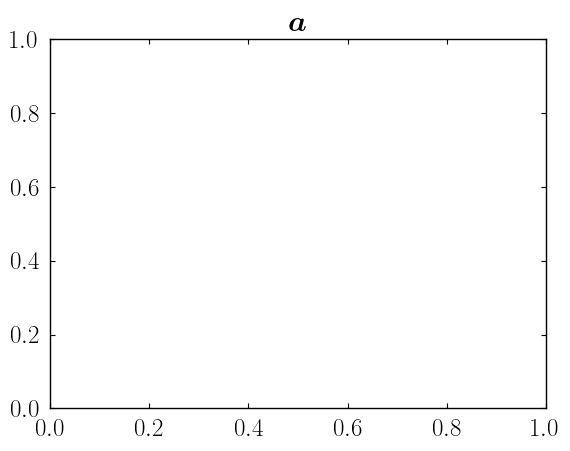

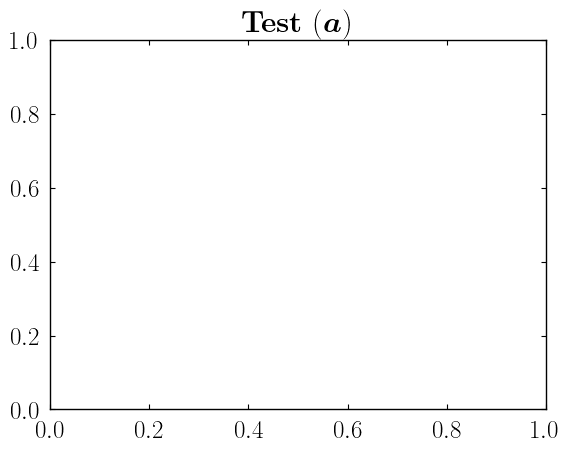

In [14]:
import matplotlib.pyplot as plt

# 关键配置：确保 amsmath 被加载
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

fig, ax = plt.subplots()

# 尝试只渲染一个最简单的粗体数学公式
try:
    ax.set_title(r'$\boldsymbol{a}$')
    print("Minimal test with r'$\\boldsymbol{a}$' succeeded!")
    plt.show()
except RuntimeError as e:
    print("Minimal test with r'$\\boldsymbol{a}$' FAILED.")
    print("Error:", e)

# ... (前面的 rcParams 设置不变)
fig, ax = plt.subplots()
ax.set_title(r'\textbf{Test} ($\boldsymbol{a}$)')
plt.show()